In [64]:
#julia version:1.11.6
include("Stability.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using PyCall
using BSplineKit

In [65]:
function eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
    sigma = 0.72
    cof = CRC_STA.Spatial_mode_BEK(F,-G,H,T,sigma,N_cheb,D,D2,R)
    A0_raw,A1_raw,A2_raw = CRC_STA.assemble_mat(cof :: CRC_STA.COF,D,D2,be,omega,R)
    A0,A1,A2 = CRC_STA.boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    # eigval = conj(eigval)
    return eigval,eigvec
end

eigsol (generic function with 1 method)

In [66]:
function interp(u0,v0,w0,T0,x,N)
    F = zeros(N+1)
    G = zeros(N+1)
    H = zeros(N+1)
    T = zeros(N+1)

    z = range(0, 20, 2000)

    itu = BSplineKit.interpolate(z, u0, BSplineOrder(4))
    itv = BSplineKit.interpolate(z, v0, BSplineOrder(4))
    itw = BSplineKit.interpolate(z, w0, BSplineOrder(4))
    itt = BSplineKit.interpolate(z, T0, BSplineOrder(4))

    for i in 1:N+1
        F[i] = itu(x[i])
        G[i] = itv(x[i])
        H[i] = itw(x[i])
        T[i] = itt(x[i])
    end

    return F, G, H, T
end

interp (generic function with 1 method)

In [ ]:
Tw = 1.1
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)

In [ ]:
plot(z,F)
plot!(z,-G)
plot!(z,H)
plot!(z,T)

In [67]:
R = 285.365
omega = 0.0
be = 0.07759
Tw = 1.1
alpha_ref = 0.384 + 0im
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
N_cheb = 99
c_ini = 0.3
num = 3
DM,D2M,x = CRC_STA.cheb_points(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)
val,vec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,c_ini,num)

(ComplexF64[0.33104402868815186 - 0.00487989397694865im, 0.20933243776147956 + 0.044973182651216255im, 0.2264535310739184 + 0.09336193918879296im], ComplexF64[0.0001374067411594221 - 0.00020187783562126168im -5.453443125707342e-5 - 0.00017648132242822716im -8.260678676853945e-6 - 2.0145212193457146e-5im; 0.0005463686710010487 - 0.0008056586966444746im -0.00021867073304493743 - 0.0007041579371448071im -3.3438984022645405e-5 - 8.175409896417997e-5im; … ; 4.1133021061500255e-16 - 6.018880597917498e-16im -8.634864741632886e-13 - 9.317408498389634e-13im 2.3715529887113895e-10 + 7.462111232744983e-10im; -2.4727286271198013e-17 + 3.709834710981678e-17im 1.0941432910675351e-13 + 3.3814036910339774e-13im 3.466722924317826e-11 - 2.3002266722166343e-10im])

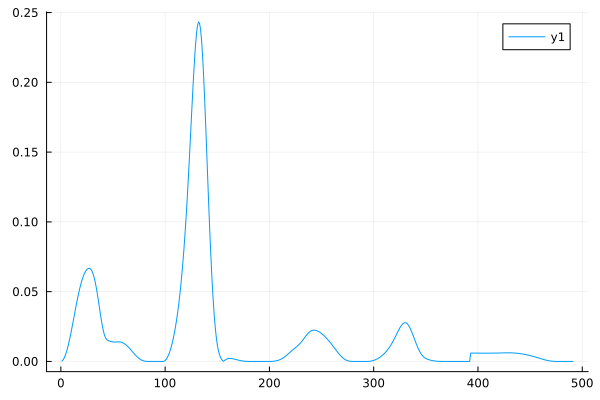

In [68]:
plot(abs.(vec[:,1]))

In [70]:
R_ini = 500
omega = 0.0
be_ini = 0.04
c_ini = 0.1
Tw = 1.1
num = 2
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
N_cheb = 69
DM,D2M,x = CRC_STA.cheb_points(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)
cur(Tw,omega,R_ini,c_ini,be_ini,num)

In [69]:
function cur(Tw,omega,R_ini,c_ini,be_ini,num)
    be_step = -0.0005
    pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
    bone = pyimport("Bone")
    z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
    N_cheb = 99
    DM,D2M,x = CRC_STA.cheb_points(N_cheb)
    F,G,H,T = interp(F,G,H,T,x,N_cheb)
    initial = []
    tempvec_1 = [0 0 0 0 0 0 0]
    eigval = 0
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval_ori,eigvec = eigsol(F,G,H,T,R_ini,omega,be_ini,N_cheb,DM,D2M,c_ini,num)
    open("output_eig.dat", "a") do io
        write(io,"be=$be_ini,eig=$eigval_ori\n")
    end
    # eigval = sort(eigval_ori, by=real)
    if imag(eigval_ori[1]) < 0
        for be = be_ini :  be_step : -0.5
            sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[end]))
            eigval,eigvec = eigsol(F,G,H,T,R_ini,omega,be,N_cheb,DM,D2M,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[end]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 || sig_last2 * sig_now2 < 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    elseif imag(eigval_ori[1]) > 0
        for be = be_ini : - be_step : 0.5
           sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[end]))
            eigval,eigvec = eigsol(F,G,H,T,R_ini,omega,be,N_cheb,DM,D2M,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[end]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 || sig_last2 * sig_now2 < 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    end
    total = initial
    be = initial[3] - be_step
    dir = 0
    boundlen = 3
 # CACULATE

    while true
        index = findall(x->x==findmin([total[end,5],total[end,7]])[1],total[end,:])
        c = total[end,index[1] - 1]
        eigval,eigvec = eigsol(F,G,H,T,total[end,2],omega,be,N_cheb,DM,D2M,c,num)
        eigval_1,eigvec = eigsol(F,G,H,T,total[end,2],omega,be-0.001,N_cheb,DM,D2M,c,num)
        eigval_2,eigvec =  eigsol(F,G,H,T,total[end,2],omega,be+0.001,N_cheb,DM,D2M,c,num)
        index1 = findmin(x-> (imag(x)) , eigval_1)[2]
        index2 = findmin(x-> (imag(x)) , eigval_2)[2]
        num = 1
        if size(total,1) > 3 && abs(total[end,2] - total[end-1,2]) <=2
            R_step = 0.25
        else
            R_step = 1
        end
        if (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) > 0) || (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) > 0) || dir == -1
            mode = 1
        elseif (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) < 0) || (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) < 0)
            mode = 2
        end
        
        if mode == 1 

            for R = total[end,2] : R_step : 700

                eigval,eigvec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,c,num)
                index = findmin((imag),eigval)[2]

                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0
                
                eigval,eigvec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end
                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 1
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end

        if mode == 1

            for R = total[end,2]: R_step : 700

                if total[end,3] == be

                    break

                end 
                
                eigval,eigvec = eigsol(F,G,H,T,R,omega,be,N_cheb,DM,D2M,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     

                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end
        c = total[end,4]
        eigval,eigvec = eigsol(F,G,H,T,total[end,2] + 2,omega,be,N_cheb,DM,D2M,c,num)
        sig = findmin(imag,eigval)[1]
        if size(total,1) > 10 &&total[end,3] != be 
            dir = -1 
            be_step = 0.0009
        else
            if sig > 0
                dir = -1
                be_step = 0.00075
            else
                dir = 1
                be_step = 0.00075
            end
        end
            be += 0.0008
        filename = "ome=$(omega)_Tw=$(Tw).dat"
        str1 = "Variables=\"omega\" \"R\" \"beta\" \"alpha_r_1\" \"alpha_i_1\" \"alpha_r_2\" \"alpha_i_2\""
        str2 = "Zone T=\"omega=$(omega),Tw=$(Tw)\""
        open(filename,"w") do io
            println(io,str1)
            println(io,str2)
            writedlm(io,total[2:end,:])
        end
        if total[end,2] > 500 && size(total,1) > 30 
            break
        end
        # app = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat")
        # ori = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
        # if app[end,2] < ori[3,2]
        #     break
        # end
    end
end

cur (generic function with 2 methods)